<a href="https://colab.research.google.com/github/MRafaelGit/MRafaelGit/blob/main/Projeto3_M13_RafaelMOliveira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [ ]:
df = pd.read_csv("Projeto3.csv", delimiter=';')

df.head(10)

,"title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria"
0,"Pack 12 un, Leche extra proteína 1 L,Loncolech..."
1,"Pack 12 un, Leche chocolate receta original 1 ..."
2,"Pack 12 un, Leche semidescremada chocolate 1 L..."
3,"Pack 12 un, Leche semidescremada frutilla 1 L,..."
4,"Pack 12 un, Leche sin lactosa chocolate 1 L,Lo..."
5,"Pack 12 un, Leche sin lactosa frutilla 1 L,Lon..."
6,"Pack 12 un, Leche saborizada light chocolate 1..."
7,"Pack 12 un, Leche saborizada frutilla 1 L,Colu..."
8,"Pack 12 un, Leche saborizada vainilla 1 L,Colu..."
9,"Pack 12 un, Leche saborizada manjar 1 L,Colun,..."


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [ ]:
media_por_categoria = df.groupby('Categoria')['Preco_Normal'].mean()

print("Média de Preço Normal por Categoria:")
print(media_por_categoria)

Média de Preço Normal por Categoria:
Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64


In [ ]:
mediana_por_categoria = df.groupby('Categoria')['Preco_Normal'].median()

print("Mediana de Preço Normal por Categoria:")
print(mediana_por_categoria)


Mediana de Preço Normal por Categoria:
Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64


Respondendo: Vou colocar as três categorias em que a média e a mediana estão mais distantes númericamente, belleza-y-cuidado-personal, congelados e lacteos, em que a média estão muito acima da mediana. Por fim as demais categorias que estão um pouco maior são frutas, instantaneos-y-sopas e verduras, e as que estão abaixo são comidas-preparadas.


# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [ ]:
desvio_padrao_por_categoria = df.groupby('Categoria')['Preco_Normal'].std()

print("Desvio Padrão de Preço Normal por Categoria:")
print(desvio_padrao_por_categoria)

Desvio Padrão de Preço Normal por Categoria:
Categoria
belleza-y-cuidado-personal    2210.041719
comidas-preparadas            2019.911428
congelados                    2111.539896
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
lacteos                       3925.816164
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


Respondendo: Comparando a média e mediana para as categorias de belleza-y-cuidado-personal, congelados e lacteos, estão muito distantes entre si, principalmente para a categoria de lacteos, isso me diz que essas categorias possuem preços_normal muito distantes entre si, e pela mediana penso na possibilidade de muitos outliers para essas três categorias.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

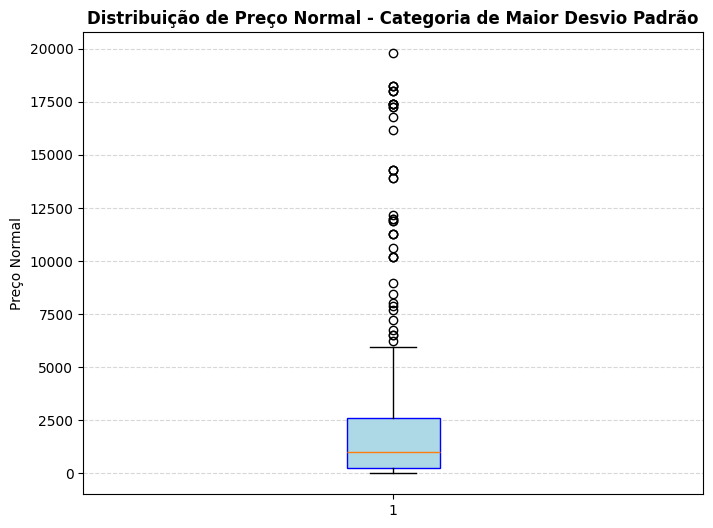

In [ ]:
dados_filtrados = df.loc[df['Categoria'] == 'lacteos']

plt.figure(figsize=(8, 6))
plt.boxplot(dados_filtrados['Preco_Normal'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'))

plt.title('Distribuição de Preço Normal - Categoria de Maior Desvio Padrão', fontsize=12, fontweight='bold')
plt.ylabel('Preço Normal')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Respondendo: Pelo boxplot, é possível visualizar que o normal, é a distribuição dos valores para a categoria lacteos entre 0 a 2500 mais ou menos. Porém, pelo bosplot é possível visualizar muitos outliers com preços muito acima do Q3 e acima até mesmo do limite superior, e nenhum preço abaixo ou outliers menores.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

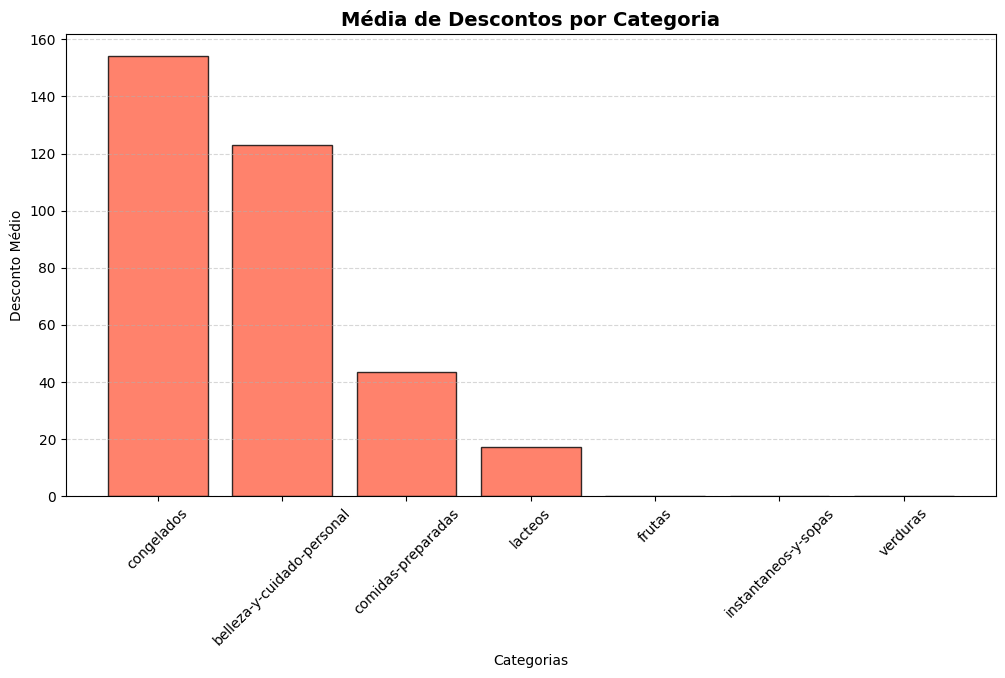

In [ ]:
media_desconto_categoria = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(media_desconto_categoria.index, media_desconto_categoria.values,
        color='tomato', edgecolor='black', alpha=0.8)

plt.title('Média de Descontos por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categorias')
plt.ylabel('Desconto Médio')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [ ]:
df_mapa = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

fig = px.treemap(
    df_mapa,
    path=['Categoria', 'Marca'],
    color='Desconto',
    color_continuous_scale='Reds',
    title='Mapa Interativo: Média de Desconto por Categoria e Marca'
)

fig.update_layout(title_x=0.5, margin=dict(t=50, l=25, r=25, b=25))

fig.show()
